---
title: "Wilkinson's high-pressure bubble-column holdup correlation"
description: "Four equations that predict gas holdup from fluid properties alone. Run end to end they say something startling at atmospheric pressure: the homogeneous regime does not exist. That single failure accounts for everything else."
categories: [sec:F, struct:S1, tier:T1, data:tier4, phase:gas-liquid]
date: 2026-07-31
---

# Wilkinson's high-pressure bubble-column holdup correlation

**Catalog ID:** `F1.3` · **Structures:** `S1` (algebraic closure) · **Tier:** T1

Wilkinson, Spek and van Dierendonck published a set of four equations that turn
fluid properties and a superficial gas velocity into a gas holdup — no column
diameter, no distributor, no fitted constant for the system at hand. It was
written for **scale-up of high-pressure bubble columns**, and pressure enters it
in exactly one place: the gas density.

This page runs those four equations end to end and asks where they are
well-posed. The answer turns out to be sharp, and it is not the answer the
correlation's reputation would suggest.

## Background

Above roughly 0.1 m/s a bubble column runs churn-turbulent, and the gas splits
into two populations: **small bubbles** that travel with the liquid, and fast
**large bubbles** that short-circuit the column. Design needs the split, because
the large bubbles carry most of the throughput and almost none of the residence
time.

Wilkinson's correlation constructs that split from a **regime transition**. Below
a transition velocity $U_{\mathrm{trans}}$ the column is homogeneous and all gas
is small bubbles; above it, the small-bubble holdup freezes at its transition
value and every additional cubic metre of gas goes into large bubbles rising at
$V_b$. So the whole correlation pivots on one number — where the transition is —
and that number is set by an exponential in the gas density.

**A note on the source, because it defines what this page can claim.** The
original paper, *AIChE Journal* **38**(4) 544–554 (1992), was not available. What
is used here is the correlation **as reprinted in full by Krishna and Ellenberger
(1996)**, their Eqs. 1–4, verified equation by equation on 600 dpi renders of
that paper. Krishna and Ellenberger are testing Wilkinson's correlation and
replacing it, so they are a hostile witness rather than a neutral one; every
statement on this page that depends on their opinion is marked as theirs. What
does *not* depend on them is the algebra, which is what most of this page is
about. Wilkinson et al. (1992) are cited as the origin of the result; Krishna and
Ellenberger (1996) are cited as the text these equations were read from.

**What this page is, next to `F1.4`.** [`F1.4`](../F1.4-krishna-ellenberger-holdup/)
tests Krishna and Ellenberger's replacement correlation, Eq. 19, against their
Figure 11, and uses Wilkinson only as the foil — evaluating its rise-velocity
equations at the plotted abscissa and never touching its transition equation at
all. This page runs the correlation as a correlation: Eq. 2 included, from
operating conditions, and the transition equation is where everything happens.

## The published model

Wilkinson et al. (1992), as printed in Krishna & Ellenberger (1996) Eqs. 1–4.
All four were read off a 600 dpi render of journal page 2627.

**(1) The split.**

$$
\varepsilon_b = \frac{U - U_{\mathrm{trans}}}{V_b},
\qquad
\varepsilon = \varepsilon_{\mathrm{small}} + \varepsilon_b .
$$

Above the transition the small-bubble holdup is frozen:
$\varepsilon_{\mathrm{small}} = \varepsilon_{\mathrm{trans}}$. That is stated in
the running text of page 2628, not in the equations, and again on page 2633 where
the total holdup is assembled.

**(2) The transition.**

$$
U_{\mathrm{trans}} = \varepsilon_{\mathrm{trans}} V_{\mathrm{small}},
\qquad
\varepsilon_{\mathrm{trans}} = 0.5\,\exp\!\left(-193\,\rho_G^{-0.61}\mu_L^{0.5}\sigma^{0.11}\right).
$$

**(3) The small-bubble rise velocity.**

$$
\frac{V_{\mathrm{small}}\,\mu_L}{\sigma}
= 2.25\left(\frac{\sigma^3\rho_L}{g\mu_L^4}\right)^{-0.273}
\left(\frac{\rho_L}{\rho_G}\right)^{0.03}.
$$

**(4) The large-bubble rise velocity.**

$$
\frac{V_b\,\mu_L}{\sigma}
= \frac{V_{\mathrm{small}}\,\mu_L}{\sigma}
+ 2.4\left(\frac{(U-U_{\mathrm{trans}})\mu_L}{\sigma}\right)^{0.757}
\left(\frac{\sigma^3\rho_L}{g\mu_L^4}\right)^{-0.077}
\left(\frac{\rho_L}{\rho_G}\right)^{0.077}.
$$

**These four equations are explicit, not coupled.** It is worth saying plainly,
because the notation suggests otherwise: $\varepsilon_{\mathrm{trans}}$ does not
contain $U$, so Eq. 2 evaluates first, then Eq. 3, then Eq. 4, then Eq. 1. There
is no iteration anywhere and no implicit transition solve. The only place a
numerical solve is needed is the *inverse* problem — given a required
$\varepsilon_b$, find the velocity — and that is well-posed for a separate
reason, checked below.

**Two things the correlation does not contain.** No column diameter, and no
distributor. Wilkinson's is a fluid-property correlation; the column is
irrelevant to it. Hold that thought.

**The alternative transition closure**, printed in the same source as Reilly et
al. (1994) Eq. 8, with $B = 3.85$ from Krishna and Ellenberger's running text:

$$
\varepsilon_{\mathrm{trans}} = 0.59\,B^{1.5}\sqrt{\frac{\rho_G^{0.96}}{\rho_L}\,\sigma^{0.12}},
\quad
V_{\mathrm{small}} = \frac{1}{2.84}\,\rho_G^{-0.04}\sigma^{0.12},
\quad
U_{\mathrm{trans}} = V_{\mathrm{small}}\,\varepsilon_{\mathrm{trans}}(1-\varepsilon_{\mathrm{trans}}).
$$

Having two closures for the same quantity, printed side by side and applicable to
the same systems, is the single most useful thing about this source: it lets each
be tested against the other without a figure.

## Parameters and assumptions

**Assumptions carried into every evaluation below.**

- Churn-turbulent operation, $U > U_{\mathrm{trans}}$. Below the transition
  Eq. 1 returns a negative $\varepsilon_b$ and is meaningless; the code clips at
  zero and the plots start above it.
- Newtonian liquid with a single dynamic viscosity. Eqs. 3 and 4 take one $\mu_L$,
  so the paper's polyacrylamide solutions — for which Table 2 prints four
  zero-shear viscosities and no single value — are excluded throughout.
- $\varepsilon_{\mathrm{small}} = \varepsilon_{\mathrm{trans}}$ above the
  transition, as the source states.
- $g = 9.81$ m/s², the value the source's notation list gives.

**Sign and direction convention, used everywhere on this page:** deviation is
always
$(\text{model} - \text{measured})/\text{measured}$,
so a positive number always means the correlation predicts more holdup than was
measured. `F1.4` learned this the hard way — at 14 % scatter a ratio and its
reciprocal are not interchangeable — and the two pages therefore use the same
convention and are directly comparable.

**Pressure.** Nothing in Eqs. 1–4 is a pressure. Pressure enters only through
$\rho_G$, so a gas substitution at 1 bar and a pressurisation of the same gas are
the same experiment as far as this correlation is concerned. That is what makes
the four-gas data set below a legitimate pressure surrogate, and it is why the
density axis on the last figure carries a second scale in bar.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "F1.3-wilkinson-high-pressure-holdup"
F14 = "F1.4-krishna-ellenberger-holdup"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
G = 9.81

## The data

Four sources, none of them new, and two of them not a dataset at all.

1. **63 marker positions from Figure 11**, digitised and maintainer-reviewed for
   the `F1.4` page. Loaded **cross-page** rather than copied. These are
   measurements of $\varepsilon_b$ in a 0.10 m column with tetradecane at four
   gas densities, and they are the only experimental data on this page.
2. **Table 2's liquid properties**, transcribed here from a 600 dpi render — five
   liquids, of which four are Newtonian and usable.
3. **Table 3's average relative deviations**, already transcribed on the `F1.4`
   page. These are the *authors'* statistics over 1,735 runs whose raw values are
   not published. They are context, not a target.
4. **Six numbers read by eye off Figure 6** — three
   $(\rho_G, \varepsilon_{df})$ pairs from panel (a) and three
   $(\rho_G, U_{df})$ pairs from panel (b), at the three gas densities that
   figure labels. *The panels themselves carry no (a)/(b) marks, and the
   velocity panel is printed above the voidage one, so the caption is the only
   authority: "Influence of gas density on the (a) dense-phase gas voidage, and
   (b) superficial gas velocity through the dense phase". An earlier version of
   this page named the two panels the other way round in prose while the code
   comment quoted the caption correctly; the values were never affected.*
   They are read against the printed axis ticks to two significant figures, with no software digitisation and no coordinates
   extracted. **They are plot markers, not a dataset**: no CSV, no sidecar, and
   none of the four validation checks below uses them. They replace a pair of
   coarser one-significant-figure bands that an earlier draft of this page
   carried, and that turned out to be wrong at the low-density end — see the
   honest-limits list.

**Inherit `F1.4`'s caveat about the gas labels.** The four series on Figure 11
differ only by marker shape, drawn as overlapping open outlines; the maintainer
review found the positions trustworthy and the shapes not. Every row except the
SF₆ group is therefore `unassigned`, and **no test on this page may depend on
series identity**. The tests below obey that: the correlation comparison uses
positions only, and the one place gas density is needed per point is flagged and
handled as a range across the four gases rather than a per-point assignment.

In [3]:
obs = load_data("krishna-ellenberger-1996-fig11.csv", page=F14)
par = load_data("krishna-ellenberger-1996-parameters.csv", page=F14)
liq = load_data("krishna-ellenberger-1996-table2-liquids.csv", page=PAGE)
obs_meta = load_meta("krishna-ellenberger-1996-fig11.csv", page=F14)
liq_meta = load_meta("krishna-ellenberger-1996-table2-liquids.csv", page=PAGE)
P = dict(zip(par.quantity, par.value))

D_T = P["column_diameter"]
B_REILLY = P["reilly_constant_B"]
GAS = {"helium": P["rho_G_helium"], "air": P["rho_G_air"],
       "argon": P["rho_G_argon"], "SF6": P["rho_G_SF6"]}

# SI properties for the Newtonian liquids of Table 2
newt = liq[liq.newtonian == "yes"].copy()
LIQ = {r.liquid: (r.density_kg_m3, r.viscosity_mPa_s * 1e-3, r.surface_tension_mN_m * 1e-3)
       for r in newt.itertuples()}
TETRA = LIQ["Tetradecane"]

x_obs = obs.U_minus_Udf.values          # (U - U_df), measured U_df, as the caption states
y_obs = obs.eps_b.values                # large-bubble holdup
is_sf6 = (obs.gas == "SF6").values

# Figure 6, read by eye against the printed axis ticks, two significant figures,
# no software digitisation. Both panels are LINEAR: 0-0.2 for eps_df and
# 0-0.05 m/s for U_df, over rho_G = 0-2 kg/m3, with three labelled markers each.
# The caption reads "Influence of gas density on the (a) dense-phase gas
# voidage, and (b) superficial gas velocity through the dense phase", so eps_df
# is panel (a) and U_df is panel (b). NOT a dataset - see the section above.
FIG6_RHO = np.array([0.18, 1.30, 1.83])          # helium, air, argon
FIG6_EPS_DF = np.array([0.089, 0.139, 0.192])    # Fig. 6(a)
FIG6_U_DF = np.array([0.0161, 0.0230, 0.0269])   # Fig. 6(b)

print(newt[["liquid", "density_kg_m3", "viscosity_mPa_s", "surface_tension_mN_m"]]
      .to_string(index=False))
print(f"\n{len(obs)} digitised points, {is_sf6.sum()} carrying a gas label; "
      f"(U-U_df) {x_obs.min():.4f}-{x_obs.max():.4f} m/s, eps_b {y_obs.min():.3f}-{y_obs.max():.3f}")
print(f"gas densities, kg/m3: " + ", ".join(f"{k} {v}" for k, v in GAS.items()))
print(f"column {D_T} m, tetradecane; Reilly B = {B_REILLY}")
print(f"\nTable 3, the authors' own deviations over ND = 1735 churn-turbulent runs:")
print(f"   eps_b : Wilkinson eqs. 1-4 {P['delta_eps_b_wilkinson']:.2f}"
      f"   their eqs. 8+19 {P['delta_eps_b_this_work']:.2f}")
print(f"   eps   : Wilkinson eqs. 1-4 {P['delta_eps_total_wilkinson']:.2f}"
      f"   their eqs. 8+19+20 {P['delta_eps_total_this_work']:.2f}")
print("\nFigure 6, read by eye off the printed ticks (markers only, not a dataset):")
for r, e, u in zip(FIG6_RHO, FIG6_EPS_DF, FIG6_U_DF):
    print(f"   rho_G {r:5.2f} kg/m3   eps_df {e:.3f}   U_df {u:.4f} m/s")
print("   the paper's own text: 'increasing gas density significantly increases")
print("   the dense-phase gas voidage (cf. Figure 6)' - the direction is printed,")
print("   these three points only put a scale on it.")

print(f"\n{cite_data(obs_meta)}")
print(f"review verdict: {obs_meta['review']['verdict']}")
print(f"{cite_data(liq_meta)}")

             liquid  density_kg_m3  viscosity_mPa_s  surface_tension_mN_m
Demineralized water            998              1.0                    72
        Tetradecane            763              2.2                    27
   Paraffin oil (A)            795              2.3                    28
   Paraffin oil (B)            790              2.9                    28

63 digitised points, 12 carrying a gas label; (U-U_df) 0.0143-0.3662 m/s, eps_b 0.029-0.241
gas densities, kg/m3: helium 0.18, air 1.3, argon 1.83, SF6 6.7
column 0.1 m, tetradecane; Reilly B = 3.85

Table 3, the authors' own deviations over ND = 1735 churn-turbulent runs:
   eps_b : Wilkinson eqs. 1-4 1.25   their eqs. 8+19 0.16
   eps   : Wilkinson eqs. 1-4 0.24   their eqs. 8+19+20 0.23

Figure 6, read by eye off the printed ticks (markers only, not a dataset):
   rho_G  0.18 kg/m3   eps_df 0.089   U_df 0.0161 m/s
   rho_G  1.30 kg/m3   eps_df 0.139   U_df 0.0230 m/s
   rho_G  1.83 kg/m3   eps_df 0.192   U_df 0.0269 m/

## PyMRM implementation

**This is an algebraic closure, not a discretised model, and dressing it as one
would be dishonest.** Eqs. 1–4 are four explicit expressions; there is no
gradient, no divergence, no Newton solve, and nothing for pymrm's operators to
do. `F1.4` says the same about the correlation that replaced it, and the reason
is the same: what these correlations are *for* is to be consumed by a reactor
model. The churn-turbulent bubble column with large bubbles in near-plug-flow
over a well-mixed dense phase is a genuine `S7` coupling, and it is
[`F2.3`](../F2.3-slurry-bubble-column-ft/); $\varepsilon_b$ is one of its
closures.

So what follows is the correlation as five functions, written to be lifted.

In [4]:
def morton(liquid=TETRA):
    """The inverse-Morton group sigma^3 rho_L / (g mu_L^4) that Eqs. 3 and 4 use."""
    rho_L, mu_L, sig = liquid
    return sig ** 3 * rho_L / (G * mu_L ** 4)


def wilkinson_transition(rho_G, liquid=TETRA):
    """Wilkinson et al. (1992) Eqs. 2 and 3. Returns (eps_trans, V_small, U_trans).

    Note that eps_trans does not depend on U: the transition is fixed by the
    fluid properties alone, so this is an evaluation and not a solve.
    """
    rho_L, mu_L, sig = liquid
    rho_G = np.asarray(rho_G, float)
    eps_trans = 0.5 * np.exp(-193.0 * rho_G ** -0.61 * mu_L ** 0.5 * sig ** 0.11)
    v_small = 2.25 * morton(liquid) ** -0.273 * (rho_L / rho_G) ** 0.03 * sig / mu_L
    return eps_trans, v_small, eps_trans * v_small


def wilkinson_vb(excess, rho_G, liquid=TETRA):
    """Wilkinson Eq. 4, the large-bubble rise velocity, at excess = U - U_trans."""
    rho_L, mu_L, sig = liquid
    _, v_small, _ = wilkinson_transition(rho_G, liquid)
    ex = np.maximum(np.asarray(excess, float), 0.0)
    return (v_small + 2.4 * (ex * mu_L / sig) ** 0.757 * morton(liquid) ** -0.077
            * (rho_L / np.asarray(rho_G, float)) ** 0.077 * sig / mu_L)


def wilkinson(U, rho_G, liquid=TETRA, excess_given=False):
    """The full correlation, Eqs. 1-4, end to end.

    U is the superficial gas velocity; with excess_given=True it is instead
    (U - U_trans) already, which is what Figure 11's model curves plot against.
    Returns a dict of every intermediate, because the intermediates are the
    point of this page.
    """
    eps_trans, v_small, u_trans = wilkinson_transition(rho_G, liquid)
    ex = np.asarray(U, float) if excess_given else np.maximum(np.asarray(U, float) - u_trans, 0.0)
    v_b = wilkinson_vb(ex, rho_G, liquid)
    eps_b = ex / v_b
    return dict(eps_trans=eps_trans, V_small=v_small, U_trans=u_trans, excess=ex,
                V_b=v_b, eps_b=eps_b, eps=eps_trans + eps_b)


def reilly_transition(rho_G, liquid=TETRA, B=None):
    """Reilly et al. (1994) Eq. 8. Returns (eps_trans, V_small, U_trans)."""
    rho_L, _, sig = liquid
    B = B_REILLY if B is None else B
    rho_G = np.asarray(rho_G, float)
    eps = 0.59 * B ** 1.5 * np.sqrt(rho_G ** 0.96 / rho_L * sig ** 0.12)
    v_small = (1.0 / 2.84) * rho_G ** -0.04 * sig ** 0.12
    return eps, v_small, v_small * eps * (1.0 - eps)


def eq19(excess, d_t=None):
    """Krishna & Ellenberger Eq. 19, the replacement. No fluid property enters."""
    d_t = D_T if d_t is None else d_t
    return 0.268 * d_t ** -0.18 * np.asarray(excess, float) ** 0.58


print("Wilkinson eqs. 1-4 evaluated end to end, air-tetradecane, U = 0.20 m/s:")
w = wilkinson(0.20, GAS["air"])
for k in ("eps_trans", "V_small", "U_trans", "excess", "V_b", "eps_b", "eps"):
    print(f"   {k:10s} {float(w[k]):.6g}")

Wilkinson eqs. 1-4 evaluated end to end, air-tetradecane, U = 0.20 m/s:
   eps_trans  0.00280116
   V_small    0.245819
   U_trans    0.000688579
   excess     0.199311
   V_b        0.777898
   eps_b      0.256218
   eps        0.259019


## Results

### Start with the transition, because it is where the correlation is most wrong

Evaluate Eq. 2 for the four gases of Figure 11 and for the four Newtonian liquids
of Table 2, alongside Reilly's Eq. 8 for the same systems. The two closures are
answering the identical question, from the identical inputs.

In [5]:
rows = []
for gas, rg in GAS.items():
    ew, vw, uw = wilkinson_transition(rg)
    er, vr, ur = reilly_transition(rg)
    rows.append((gas, rg, float(ew), float(uw), float(er), float(ur),
                 float(er / ew), float(ur / uw)))
tab = pd.DataFrame(rows, columns=["gas", "rho_G", "eps_tr_W", "U_tr_W",
                                  "eps_tr_R", "U_tr_R", "ratio_eps", "ratio_U"])
print("air-to-SF6 gases in tetradecane, D_T = 0.10 m\n")
print(tab.to_string(index=False, float_format=lambda v: f"{v:12.4g}"))

print("\n\nair in each Newtonian liquid of Table 2\n")
rows = []
for name, props in LIQ.items():
    ew, vw, uw = wilkinson_transition(GAS["air"], props)
    er, vr, ur = reilly_transition(GAS["air"], props)
    rows.append((name, props[0], props[1] * 1e3, props[2] * 1e3,
                 float(ew), float(er), float(er / ew)))
print(pd.DataFrame(rows, columns=["liquid", "rho_L", "mu_L/mPa.s", "sigma/mN.m",
                                  "eps_tr_W", "eps_tr_R", "ratio"])
      .to_string(index=False, float_format=lambda v: f"{v:10.4g}"))

print("\nEvery entry in the last column is a factor, not a percentage.")

air-to-SF6 gases in tetradecane, D_T = 0.10 m

   gas        rho_G     eps_tr_W       U_tr_W     eps_tr_R       U_tr_R    ratio_eps      ratio_U
helium         0.18    1.506e-08    3.928e-09      0.05704      0.01315    3.788e+06    3.348e+06
   air          1.3     0.002801    0.0006886       0.1474      0.02838         52.6        41.22
 argon         1.83     0.007435     0.001809       0.1736      0.03197        23.36        17.67
   SF6          6.7      0.07427      0.01738       0.3237      0.04631        4.358        2.664


air in each Newtonian liquid of Table 2

             liquid  rho_L  mu_L/mPa.s  sigma/mN.m   eps_tr_W   eps_tr_R      ratio
Demineralized water    998           1          72    0.01019     0.1367      13.42
        Tetradecane    763         2.2          27   0.002801     0.1474       52.6
   Paraffin oil (A)    795         2.3          28   0.002441     0.1447      59.28
   Paraffin oil (B)    790         2.9          28   0.001269     0.1451      114.4


The two closures disagree by a factor of 4 at SF₆, 53 at air,
and 3.8 million at helium — where Eq. 2 returns
$\varepsilon_{\mathrm{trans}} = 1.5\times10^{-8}$ and a transition velocity of
4 nm/s. Krishna and Ellenberger say Wilkinson's transition
correlation "severely underpredicts" the dense-phase voidage and velocity, and
their Figures 4 and 6 draw both closures against measurement on **logarithmic**
axes spanning three decades — which is the axis you need if one of your two
curves sits at 0.003 and your data sit at 0.15.

The reason is visible in the functional form. Eq. 2 is
$0.5\exp(-193\,\rho_G^{-0.61}\mu_L^{0.5}\sigma^{0.11})$: at small $\rho_G$ the
argument of the exponential is large and negative, and the whole thing collapses.
The prefactor 0.5 is a ceiling approached only as $\rho_G \to \infty$. So the
correlation has a **density scale** built into it, and the question is where that
scale sits.

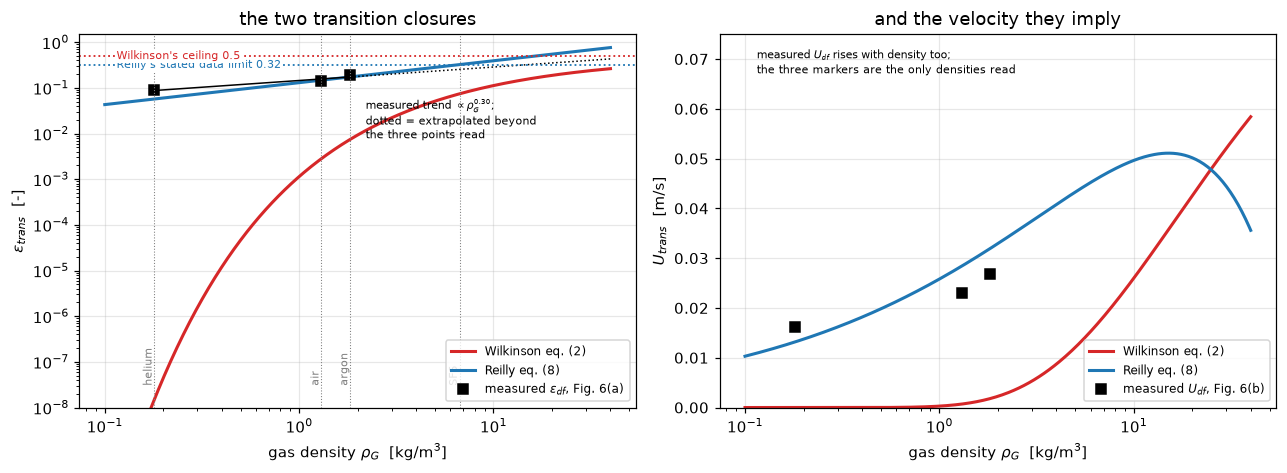

how far eq. (2) is below the measurement, at the three densities Fig. 6 gives:
   rho_G  0.18: measured 0.089, eq. 2   1.506e-08, low by a factor    5.91e+06  (6.8 decades)
   rho_G  1.30: measured 0.139, eq. 2    0.002801, low by a factor       49.62  (1.7 decades)
   rho_G  1.83: measured 0.192, eq. 2    0.007435, low by a factor       25.83  (1.4 decades)

does the gap close as the density rises? the two closures never cross:
      rho_G     eq. 2     eq. 8   eq.8/eq.2
       0.18 1.506e-08   0.05704   3.788e+06
       1.30  0.002801    0.1474        52.6
       6.70   0.07427    0.3237       4.358
      25.00    0.2128    0.6091       2.862
      70.00     0.317    0.9984        3.15
    1000.00     0.457     3.578        7.83
   the ratio bottoms out at 2.85 near rho_G = 29 kg/m3 and rises
   again; eq. 2 is BELOW eq. 8 at every density from 0.1 to 1000 kg/m3.

Eq. (2) crosses a FIXED 0.15 at rho_G = 14.2 kg/m3 (~11 bar of air).
But the target is not fixed. The paper states that i

In [6]:
rho = np.logspace(np.log10(0.1), np.log10(40), 400)
eW, vW, uW = wilkinson_transition(rho)
eR, vR, uR = reilly_transition(rho)

# the measured trend, over the range it was read on and nowhere else
p_eps = np.polyfit(np.log(FIG6_RHO), np.log(FIG6_EPS_DF), 1)
rho_meas = np.logspace(np.log10(FIG6_RHO.min()), np.log10(FIG6_RHO.max()), 40)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
ax = axes[0]
ax.loglog(rho, eW, "-", lw=2, color="tab:red", label="Wilkinson eq. (2)")
ax.loglog(rho, eR, "-", lw=2, color="tab:blue", label="Reilly eq. (8)")
ax.loglog(FIG6_RHO, FIG6_EPS_DF, "ks", ms=6, label=r"measured $\varepsilon_{df}$, Fig. 6(a)")
ax.loglog(rho_meas, np.exp(np.polyval(p_eps, np.log(rho_meas))), "k-", lw=1.0)
ax.loglog(np.logspace(np.log10(FIG6_RHO.max()), np.log10(40), 40),
          np.exp(np.polyval(p_eps, np.log(np.logspace(np.log10(FIG6_RHO.max()),
                                                      np.log10(40), 40)))),
          "k:", lw=1.0)
ax.text(2.2, 0.062, f"measured trend $\\propto\\rho_G^{{{p_eps[0]:.2f}}}$;\n"
        "dotted = extrapolated beyond\nthe three points read",
        fontsize=7.0, va="top")
ax.axhline(0.32, color="tab:blue", ls=":", lw=1.2)
lbl = dict(fontsize=7.5, va="center",
           bbox=dict(facecolor="white", edgecolor="none", pad=1.0))
ax.text(0.115, 0.32, "Reilly's stated data limit 0.32", color="tab:blue", **lbl)
ax.axhline(0.5, color="tab:red", ls=":", lw=1.2)
ax.text(0.115, 0.5, "Wilkinson's ceiling 0.5", color="tab:red", **lbl)
for g, v in GAS.items():
    ax.axvline(v, color="grey", lw=0.7, ls=":")
    ax.text(v, 3e-8, g, rotation=90, fontsize=7.5, ha="right", va="bottom", color="grey")
ax.set(xlabel=r"gas density $\rho_G$  [kg/m$^3$]", ylabel=r"$\varepsilon_{trans}$  [-]",
       ylim=(1e-8, 1.5), title="the two transition closures")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
ax.semilogx(rho, uW, "-", lw=2, color="tab:red", label="Wilkinson eq. (2)")
ax.semilogx(rho, uR, "-", lw=2, color="tab:blue", label="Reilly eq. (8)")
ax.semilogx(FIG6_RHO, FIG6_U_DF, "ks", ms=6, label=r"measured $U_{df}$, Fig. 6(b)")
ax.text(0.115, 0.072, "measured $U_{df}$ rises with density too;\n"
        "the three markers are the only densities read",
        fontsize=7.0, va="top")
ax.set(xlabel=r"gas density $\rho_G$  [kg/m$^3$]",
       ylabel=r"$U_{trans}$  [m/s]", ylim=(0, 0.075),
       title="and the velocity they imply")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

print("how far eq. (2) is below the measurement, at the three densities Fig. 6 gives:")
for r, e in zip(FIG6_RHO, FIG6_EPS_DF):
    ew = float(wilkinson_transition(r)[0])
    print(f"   rho_G {r:5.2f}: measured {e:.3f}, eq. 2 {ew:11.4g}, low by a factor "
          f"{e/ew:11.4g}  ({np.log10(e/ew):.1f} decades)")

print("\ndoes the gap close as the density rises? the two closures never cross:")
print(f"   {'rho_G':>8}{'eq. 2':>10}{'eq. 8':>10}{'eq.8/eq.2':>12}")
for r in (0.18, 1.3, 6.7, 25.0, 70.0, 1000.0):
    print(f"   {r:8.2f}{float(wilkinson_transition(r)[0]):10.4g}"
          f"{float(reilly_transition(r)[0]):10.4g}"
          f"{float(reilly_transition(r)[0])/float(wilkinson_transition(r)[0]):12.4g}")
rr = np.logspace(-1, 3, 20001)
ratio_R_over_W = reilly_transition(rr)[0] / wilkinson_transition(rr)[0]
i_min = int(np.argmin(ratio_R_over_W))
min_ratio, rho_min_ratio = float(ratio_R_over_W[i_min]), float(rr[i_min])
print(f"   the ratio bottoms out at {min_ratio:.2f} near rho_G = {rho_min_ratio:.0f} kg/m3 and rises")
print(f"   again; eq. 2 is BELOW eq. 8 at every density from 0.1 to 1000 kg/m3.")

r15 = brentq(lambda r: float(wilkinson_transition(r)[0]) - 0.15, 0.5, 200)
r32 = brentq(lambda r: float(reilly_transition(r)[0]) - 0.32, 0.5, 200)
r1 = brentq(lambda r: float(reilly_transition(r)[0]) - 1.0, 0.5, 500)
eps_meas_at_r15 = float(np.exp(np.polyval(p_eps, np.log(r15))))
print(f"\nEq. (2) crosses a FIXED 0.15 at rho_G = {r15:.1f} kg/m3 "
      f"(~{r15/GAS['air']:.0f} bar of air).")
print("But the target is not fixed. The paper states that increasing gas density")
print("significantly increases the dense-phase voidage, and the three points read")
print(f"off Fig. 6(a) put that rise at eps_df ~ rho_G^{p_eps[0]:.2f}. Extrapolating that")
print(f"three-point fit to {r15:.1f} kg/m3 gives a measured level of {eps_meas_at_r15:.2f}, where eq. 2")
print(f"would still be a factor {eps_meas_at_r15/0.15:.1f} low. So {r15:.0f} kg/m3 is a LOWER BOUND on where")
print("eq. 2 could become adequate, not the density at which it does - and the")
print("extrapolation is a reconstruction from three read points, not a measurement.")

print(f"\nReilly eq. (8) reaches its own stated data limit 0.32 at rho_G = {r32:.2f} kg/m3")
print(f"   -> SF6 at {GAS['SF6']} kg/m3 already gives {float(reilly_transition(GAS['SF6'])[0]):.3f}, just past it")
print(f"Reilly eq. (8) reaches the impossible eps_trans = 1 at rho_G = {r1:.0f} kg/m3")
rpk = float(rho[np.argmax(uR)])
print(f"and its U_trans is non-monotone: it peaks at rho_G = {rpk:.0f} kg/m3 and falls")
print(f"   beyond, because of the (1 - eps_trans) factor - another reason not to")
print(f"   extrapolate it.")

**This is the central result of the page, and it is the
authors' own finding made specific.** Krishna and Ellenberger write that "the
Wilkinson correlation severely underpredicts the values of the voidage and gas
velocity through the dense phase", and they compare Eq. 2 against their measured
$\varepsilon_{df}$ themselves, taking
$\varepsilon_{df} = \varepsilon_{\mathrm{trans}}$. This page runs the same
comparison and puts numbers on "severely": Eq. 2 is **1.7 decades below the
measurement at air and 1.4 at argon, and 6.8 decades below it at helium**, where
it returns $\varepsilon_{\mathrm{trans}} = 1.5\times10^{-8}$ and a transition
velocity of 4 nm/s. The small-bubble population is not merely underpredicted at
helium; it is deleted.

**The gap does not close at higher density.** Two facts, both above:

- Eq. 2 is below Reilly's Eq. 8 at *every* density from 0.1 to 1000 kg/m³. The
  ratio bottoms out at 2.85 near 29 kg/m³ and rises again, so the two curves
  never cross — visibly so on the left panel. Nothing here shows Wilkinson
  becoming *correct* at any density, only that it stops being absurd.
- The density at which Eq. 2 crosses 0.15 is not the density at which it becomes
  adequate, because the measured level rises too. Krishna and Ellenberger state
  that outright — "while increasing gas density significantly increases the
  dense-phase gas voidage (cf. Figure 6)" — and the three points read off
  Figure 6(a) scale as $\rho_G^{0.30}$. Carried to 14 kg/m³ that trend sits near
  0.32, where Eq. 2 would still be a factor of 2.1 low. **14 kg/m³ is a lower
  bound on where Eq. 2 could become adequate, not a crossover**, and the
  extrapolation behind that sentence is a three-point reconstruction rather than
  a measurement.

**So the two closures are not complementary, and this page does not claim they
are.** They fail in opposite *directions*, which is a different and weaker
statement: Eq. 2 is low everywhere it can be tested and is hard-bounded by its
own prefactor 0.5, while Reilly's Eq. 8 is the better of the two wherever data
exist but was developed on data reaching only
$\varepsilon_{\mathrm{trans}} = 0.32$ — a ceiling Krishna and Ellenberger state
explicitly, which SF₆ at 6.7 kg/m³ already passes — beyond which it turns
non-monotone in $U_{\mathrm{trans}}$ and then leaves physics entirely at
70 kg/m³. Above 6.7 kg/m³ **neither** closure has support in this source.

The one thing that is fair to say for Wilkinson is that Krishna and Ellenberger
tested it at 0.18–6.7 kg/m³, an order of magnitude below the density its own
title names. That explains where the failure comes from; it does not repair it.

### What that does to the holdup

With $U_{\mathrm{trans}} \approx 0$ for the lighter gases, Wilkinson's Eq. 1
assigns essentially *all* the gas to large bubbles.

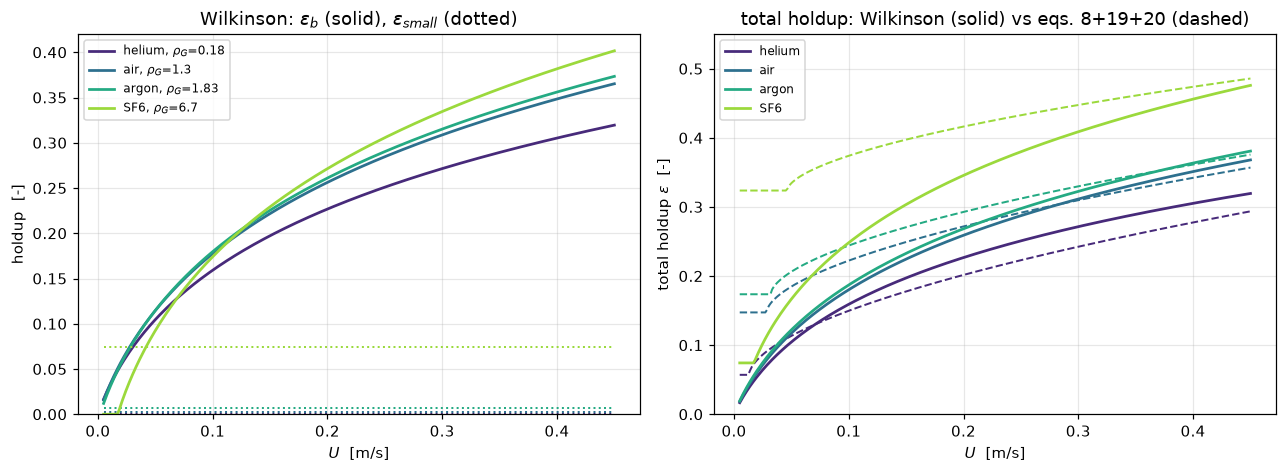

small-bubble holdup the two routes assign, air-tetradecane:
   Wilkinson eq. (2): 0.0028
   Reilly    eq. (8): 0.1474

so the dotted lines in the left panel are the entire small-bubble population
Wilkinson predicts, and for helium it is 1.5e-8 - the homogeneous regime
does not exist at all in this correlation at atmospheric helium density.


In [7]:
U = np.linspace(0.005, 0.45, 300)
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
cols = dict(zip(GAS, plt.cm.viridis(np.linspace(0.12, 0.85, 4))))

ax = axes[0]
for g, rg in GAS.items():
    w = wilkinson(U, rg)
    ax.plot(U, w["eps_b"], "-", color=cols[g], lw=1.8, label=f"{g}, $\\rho_G$={rg}")
    ax.plot(U, np.full_like(U, float(w["eps_trans"])), ":", color=cols[g], lw=1.3)
ax.set(xlabel="$U$  [m/s]", ylabel=r"holdup  [-]", ylim=(0, 0.42),
       title=r"Wilkinson: $\varepsilon_b$ (solid), $\varepsilon_{small}$ (dotted)")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
for g, rg in GAS.items():
    w = wilkinson(U, rg)
    ax.plot(U, w["eps"], "-", color=cols[g], lw=1.8, label=f"{g}")
    er = float(reilly_transition(rg)[0])
    ke = eq19(np.maximum(U - float(reilly_transition(rg)[2]), 0))
    ax.plot(U, ke + er * (1 - ke), "--", color=cols[g], lw=1.3)
ax.set(xlabel="$U$  [m/s]", ylabel=r"total holdup $\varepsilon$  [-]", ylim=(0, 0.55),
       title="total holdup: Wilkinson (solid) vs eqs. 8+19+20 (dashed)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

print("small-bubble holdup the two routes assign, air-tetradecane:")
print(f"   Wilkinson eq. (2): {float(wilkinson_transition(GAS['air'])[0]):.4f}")
print(f"   Reilly    eq. (8): {float(reilly_transition(GAS['air'])[0]):.4f}")
print("\nso the dotted lines in the left panel are the entire small-bubble population")
print("Wilkinson predicts, and for helium it is 1.5e-8 - the homogeneous regime")
print("does not exist at all in this correlation at atmospheric helium density.")

## Validation

Ranked as the gallery ranks them. There is no worked example with printed
intermediates in this source, so the strongest routes available are **internal
identities the correlation must satisfy** and the **one printed statistic**, with
the 63 measured points supplying the only genuine comparison against experiment.

Each check below says what it is: an identity, a reproduction of the authors' own
computed values, or a comparison with measurement. They are not the same thing
and the page does not blur them.

### 1. Dimensional consistency — an identity, and it fails in an informative place

Eqs. 3 and 4 are written as dimensionless groups. Eq. 2 is not written as
anything: it is a bare exponential of a dimensional product. Check all of them by
exponent arithmetic on (kg, m, s).

**Which units the constants are bound to is settled by the source itself, not by
inference.** Krishna and Ellenberger's Notation list on their page 2634 prints

> $\sigma$ = surface tension of liquid phase, N·m⁻¹
> $\mu_L$ = liquid viscosity, Pa·s
> $\rho_G$ = density of gaseous phase, kg·m⁻³

so Eq. 2 and Eq. 8 are SI-bound by declaration. That matters because both
equations are *dimensionally inhomogeneous* — their constants carry units — so
there is no non-dimensional form to fall back on, and feeding them a table of
mPa·s is not a scaling error but a catastrophe, as the last two lines below
show.

In [8]:
DIM = {"rho": np.array([1., -3, 0]), "mu": np.array([1., -1, -1]),
       "sigma": np.array([1., 0, -2]), "g": np.array([0., 1, -2]),
       "velocity": np.array([0., 1, -1])}
D = DIM

groups = {
    "Mo = sigma^3 rho_L/(g mu_L^4)": 3*D["sigma"] + D["rho"] - D["g"] - 4*D["mu"],
    "V mu_L/sigma  (eqs. 3, 4 LHS)": D["velocity"] + D["mu"] - D["sigma"],
    "(U-U_tr) mu_L/sigma (eq. 4)":   D["velocity"] + D["mu"] - D["sigma"],
    "rho_L/rho_G (eqs. 3, 4)":       D["rho"] - D["rho"],
    "eq. 2 exponent argument":       -0.61*D["rho"] + 0.5*D["mu"] + 0.11*D["sigma"],
    "eq. 8 sqrt argument":           0.96*D["rho"] - D["rho"] + 0.12*D["sigma"],
    "eq. 8 V_small - velocity":      -0.04*D["rho"] + 0.12*D["sigma"] - D["velocity"],
}
print(f"{'group':34s}{'kg':>8}{'m':>8}{'s':>8}   dimensionless?")
for name, v in groups.items():
    ok = "yes" if np.allclose(v, 0) else "NO"
    print(f"{name:34s}{v[0]:8.3f}{v[1]:8.3f}{v[2]:8.3f}   {ok}")

print("\nEvery group in Wilkinson's rise-velocity equations is exactly dimensionless.")
print("Be precise about what that checks: it catches a mis-read exponent INSIDE a")
print("group - sigma^3, mu_L^4, the mu_L/sigma scaling - because those change the")
print("dimensions. It does NOT constrain an exponent applied to an already")
print("dimensionless group (-0.273, -0.077, 0.03, 0.077, 0.757), which stays")
print("dimensionless whatever its value. The transition equations are a different")
print("matter again: nothing about them is dimensionless.")

rho_L, mu_L, sig = TETRA
si = float(0.5*np.exp(-193*GAS["air"]**-0.61 * mu_L**0.5 * sig**0.11))
cgs = float(0.5*np.exp(-193*GAS["air"]**-0.61 * (mu_L*1e3)**0.5 * (sig*1e3)**0.11))
print(f"\neq. 2 with mu_L in Pa s and sigma in N/m  : {si:.5f}")
print(f"eq. 2 with mu_L in mPa s and sigma in mN/m: {cgs:.3e}")
print("so the constant 193 carries units. The source's own Notation list (p. 2634)")
print("declares sigma in N/m, mu_L in Pa s and rho_G in kg/m3, so SI is the paper's")
print("stated convention, not this page's guess. The mass dimension happens to")
print("cancel in eq. 2 and does not in eq. 8; neither can be non-dimensionalised,")
print("and neither may be fed non-SI inputs - a trap for anyone lifting them out")
print("of a table of mPa s.")

group                                   kg       m       s   dimensionless?
Mo = sigma^3 rho_L/(g mu_L^4)        0.000   0.000   0.000   yes
V mu_L/sigma  (eqs. 3, 4 LHS)        0.000   0.000   0.000   yes
(U-U_tr) mu_L/sigma (eq. 4)          0.000   0.000   0.000   yes
rho_L/rho_G (eqs. 3, 4)              0.000   0.000   0.000   yes
eq. 2 exponent argument              0.000   1.330  -0.720   NO
eq. 8 sqrt argument                  0.080   0.120  -0.240   NO
eq. 8 V_small - velocity             0.080  -0.880   0.760   NO

Every group in Wilkinson's rise-velocity equations is exactly dimensionless.
Be precise about what that checks: it catches a mis-read exponent INSIDE a
group - sigma^3, mu_L^4, the mu_L/sigma scaling - because those change the
dimensions. It does NOT constrain an exponent applied to an already
dimensionless group (-0.273, -0.077, 0.03, 0.077, 0.757), which stays
dimensionless whatever its value. The transition equations are a different
matter again: nothing about the

### 2. Continuity at the transition — an identity about the correlation's own structure

As $U \to U_{\mathrm{trans}}^{+}$, Eq. 4 reduces to $V_b \to V_{\mathrm{small}}$,
so Eq. 1 gives
$\varepsilon_b \to (U-U_{\mathrm{trans}})/V_{\mathrm{small}} \to 0$
and $\varepsilon \to \varepsilon_{\mathrm{trans}}$. The correlation is therefore
continuous across the regime transition — and more than that, its slope
$\mathrm{d}\varepsilon_b/\mathrm{d}U \to 1/V_{\mathrm{small}}$ matches the
homogeneous branch $\varepsilon = U/V_{\mathrm{small}}$ that Eq. 2 implies below
the transition, since $\varepsilon_{\mathrm{trans}} = U_{\mathrm{trans}}/V_{\mathrm{small}}$
is exactly that branch evaluated at $U_{\mathrm{trans}}$. **The correlation is
$C^1$ across its own regime boundary.**

That only holds if the first term of Eq. 4 is *exactly* $V_{\mathrm{small}}$ from
Eq. 3 — the same expression, not merely a similar one — so the check below
establishes a structural property of the correlation, and that is all it
establishes.

**What it is not.** An earlier draft of this page fitted the *rate* at which the
limit is approached, recovered 0.7566 against Eq. 4's printed 0.757, and called
that an independent check on the transcription of the exponent. **It is not one,
and the claim has been removed.** The exponent 0.757 is typed into the function
being fitted, so the fit reads it straight back: type 0.657 and the fit
"recovers" 0.6557. The residual 0.05 % is finite-excess truncation, not
agreement. The genuine external checks on the transcription are the dimensional
identity above — including the source's own declared units — and the
reproduction of the authors' computed figure lines in §3.

In [9]:
_, v_small_air, u_tr_air = wilkinson_transition(GAS["air"])
v_small_air, u_tr_air = float(v_small_air), float(u_tr_air)

d = np.logspace(-4, -9, 12)
eb = wilkinson(d, GAS["air"], excess_given=True)["eps_b"]
rel = 1.0 - eb * v_small_air / d          # relative shortfall from the linear limit
lim_ratio = float(abs(rel[-1]))           # departure from the limit at the smallest excess

print(f"V_small(air, tetradecane) = {v_small_air:.5f} m/s,  U_trans = {u_tr_air:.6f} m/s\n")
print(f"{'U - U_trans':>12}{'eps_b':>14}{'(U-U_tr)/V_small':>20}{'1 - ratio':>14}")
for dd, ee in list(zip(d, eb))[::3]:
    print(f"{dd:12.0e}{ee:14.6e}{dd/v_small_air:20.6e}{1-ee*v_small_air/dd:14.4e}")
print(f"\n  eps_b -> (U - U_trans)/V_small as U -> U_trans, so eps -> eps_trans exactly.")
print(f"  departure from that limit at U - U_trans = {d[-1]:.0e} m/s: {lim_ratio:.2e}")
print("  -> eq. 4's first term is EXACTLY eq. 3's V_small (not merely close to it),")
print("     so the correlation is C1 across its own regime boundary. This is a")
print("     structural identity. It says nothing about whether any exponent was")
print("     transcribed correctly - the exponents are inputs to this arithmetic.")

# monotonicity and invertibility, which is the only solve the correlation needs
Ug = np.linspace(u_tr_air + 1e-6, 2.0, 4000)
ebg = wilkinson(Ug, GAS["air"])["eps_b"]
print(f"\n  d(eps_b)/dU > 0 everywhere on U in (U_trans, 2 m/s]: "
      f"{bool(np.all(np.diff(ebg) > 0))}")
for target in (0.05, 0.15, 0.30):
    Us = brentq(lambda u: float(wilkinson(u, GAS["air"])["eps_b"]) - target,
                u_tr_air + 1e-9, 50.0)
    back = float(wilkinson(Us, GAS["air"])["eps_b"])
    print(f"  inverse solve: eps_b = {target:.2f} at U = {Us:.4f} m/s "
          f"(round trip {back:.8f})")
u_eps1 = brentq(lambda u: float(wilkinson(u, GAS["air"])["eps"]) - 1.0, 0.1, 1e4)
print(f"\n  eps reaches 1 only at U = {u_eps1:.1f} m/s, far outside any column, so the")
print(f"  correlation stays physical over its whole useful range "
      f"(eps = {float(wilkinson(0.5, GAS['air'])['eps']):.3f} at U = 0.5 m/s).")

V_small(air, tetradecane) = 0.24582 m/s,  U_trans = 0.000689 m/s

 U - U_trans         eps_b    (U-U_tr)/V_small     1 - ratio
       1e-04  4.040229e-04        4.068027e-04    6.8334e-03
       4e-06  1.759828e-05        1.760952e-05    6.3836e-04
       2e-07  7.622289e-07        7.622741e-07    5.9298e-05
       8e-09  3.299684e-08        3.299703e-08    5.5055e-06

  eps_b -> (U - U_trans)/V_small as U -> U_trans, so eps -> eps_trans exactly.
  departure from that limit at U - U_trans = 1e-09 m/s: 1.13e-06
  -> eq. 4's first term is EXACTLY eq. 3's V_small (not merely close to it),
     so the correlation is C1 across its own regime boundary. This is a
     structural identity. It says nothing about whether any exponent was
     transcribed correctly - the exponents are inputs to this arithmetic.

  d(eps_b)/dU > 0 everywhere on U in (U_trans, 2 m/s]: True
  inverse solve: eps_b = 0.05 at U = 0.0170 m/s (round trip 0.05000000)
  inverse solve: eps_b = 0.15 at U = 0.0756 m/s (round 

### 3. Reproduction of the authors' own computed lines — the real transcription check

Krishna and Ellenberger plot **their** evaluation of both transition closures as
horizontal lines on the logarithmic axes of their Figure 4, for two different
liquids, and draw them again against gas density in Figure 6. Reading where those
lines sit against the printed ticks — to one significant figure, no coordinates
extracted — checks this page's transcription of Eq. 2, of Eq. 8, of $B = 3.85$,
and of the SI unit convention, all at once. With the circular exponent check
withdrawn in §2, **this and the dimensional identity are the transcription checks
the page has.** Figure 4 carries the weight, because its axes are logarithmic and
therefore resolve a number as small as $\varepsilon_{\mathrm{trans}} = 0.003$;
Figure 6's are linear and corroborate rather than quantify.

This is a **reproduction**, not a validation: it compares two evaluations of the
same equations, not a model against a measurement.

In [10]:
print(f"{'system':22s}{'eq. 2':>10}{'eq. 8':>10}   where the printed lines sit in Fig. 4")
for liq_name, panel in (("Demineralized water", "(a), air-water: eq. 2 line on the 0.01 tick, eq. 8 just above 0.1"),
                        ("Tetradecane", "(c), air-tetradecane: eq. 2 between 0.001 and 0.01, eq. 8 just above 0.1")):
    props = LIQ[liq_name]
    ew = float(wilkinson_transition(GAS["air"], props)[0])
    er = float(reilly_transition(GAS["air"], props)[0])
    print(f"{liq_name:22s}{ew:10.4f}{er:10.4f}   {panel}")
print("\nBoth panels are reproduced, including the factor of 3.6 between the two")
print("liquids' Wilkinson lines, which is visible in the figure as a clear")
print("vertical offset. Reilly's two lines differ by only 8 % and are drawn at")
print("indistinguishable heights, which is also what the figure shows.")

print("\nA second reading, on a DIFFERENT figure. Fig. 6 draws the same two closures")
print("against gas density for air-tetradecane, on LINEAR axes: 0-0.2 for eps and")
print("0-0.05 m/s for U, over rho_G = 0-2 kg/m3. What that axis can and cannot say:")
for r, seen in ((0.18, 0.055), (1.83, 0.17)):
    print(f"   Reilly eps_trans at rho_G {r:4.2f}: line read at ~{seen:.3f},"
          f" this page computes {float(reilly_transition(r)[0]):.3f}")
print("   -> the authors' own Reilly curve is reproduced to within its drawn width.")
print("   Wilkinson's curves in BOTH panels are drawn indistinguishable from zero")
print("   across the whole range. On a linear axis of full scale 0.2 that is all")
print(f"   that can be read: it cannot separate this page's {float(wilkinson_transition(0.18)[0]):.1e}")
print(f"   at helium from its {float(wilkinson_transition(1.83)[0]):.4f} at argon. So Fig. 6 CORROBORATES the")
print("   collapse and does not quantify it; Fig. 4's logarithmic axes above do.")
print("\n   One mismatch worth recording, because it is the source's and not this")
print("   page's. Reilly's U_trans as printed comes out below K&E's own drawn")
print("   Reilly curve in the velocity panel, and the gap grows with density:")
for r, seen in ((0.18, 0.016), (1.83, 0.041)):
    ur_ = float(reilly_transition(r)[2])
    print(f"      rho_G {r:4.2f}: curve read at ~{seen:.3f}, eq. 8 as printed gives"
          f" {ur_:.4f} m/s ({(ur_/seen-1)*100:+.0f} %)")
print("   Their eps_trans curve reproduces, so this is an internal inconsistency in")
print("   the source's own Fig. 6, not a transcription error here - the (1-eps_trans)")
print("   factor was verified on the render. Nothing on this page turns on it; the")
print("   abscissa-convention conclusion below is robust to a 25 % shift in U_df.")

system                     eq. 2     eq. 8   where the printed lines sit in Fig. 4
Demineralized water       0.0102    0.1367   (a), air-water: eq. 2 line on the 0.01 tick, eq. 8 just above 0.1
Tetradecane               0.0028    0.1474   (c), air-tetradecane: eq. 2 between 0.001 and 0.01, eq. 8 just above 0.1

Both panels are reproduced, including the factor of 3.6 between the two
liquids' Wilkinson lines, which is visible in the figure as a clear
vertical offset. Reilly's two lines differ by only 8 % and are drawn at
indistinguishable heights, which is also what the figure shows.

A second reading, on a DIFFERENT figure. Fig. 6 draws the same two closures
against gas density for air-tetradecane, on LINEAR axes: 0-0.2 for eps and
0-0.05 m/s for U, over rho_G = 0-2 kg/m3. What that axis can and cannot say:
   Reilly eps_trans at rho_G 0.18: line read at ~0.055, this page computes 0.057
   Reilly eps_trans at rho_G 1.83: line read at ~0.170, this page computes 0.174
   -> the authors' o

### 4. Against the 63 measured points — the only experimental test here

These are measurements, so this is validation. Figure 11's abscissa is
$(U - U_{df})$ with **measured** $U_{df}$ for the points, while the model curves
on the same axes take $U_{df} = U_{\mathrm{trans}}$ — the caption says so. Both
conventions are evaluated below, because the difference between them is exactly
the quantity this page is about, and because `F1.4` had to leave it as an open
caveat.

In [11]:
# convention A: at the plotted abscissa, which is what the figure's model curves do
eb_A = wilkinson(x_obs, GAS["air"], excess_given=True)["eps_b"]
dev_A = eb_A / y_obs - 1
dev_19 = eq19(x_obs) / y_obs - 1

print("deviation is (model - measured)/measured throughout")
print(f"Wilkinson eqs. 1-4, at the plotted abscissa, air density, all {len(x_obs)} points:")
print(f"   mean |dev| {np.abs(dev_A).mean()*100:5.1f} %   bias {dev_A.mean()*100:+5.1f} %"
      f"   worst {np.abs(dev_A).max()*100:5.1f} %")
print(f"   eq. (19) on the same points, for scale: mean |dev| {np.abs(dev_19).mean()*100:.1f} %"
      f"  bias {dev_19.mean()*100:+.1f} %   [F1.4 reports 13.8 % / +2.8 %; this page")
print("    retypes eqs. 3-4 from the same source and applies them to the same 63")
print("    rows, so that is a transcription cross-check, not an independent result]")

# how much of the headline rests on evaluating every point at air density?
print("\nthe headline +64 % assumes ALL 63 points are air. The gas labels are not")
print("reliable, so the honest statement is the span over the four gases:")
gas_bias = {}
for g, rg in GAS.items():
    dg = (wilkinson(x_obs, rg, excess_given=True)["eps_b"] / y_obs - 1).mean()
    gas_bias[g] = float(dg)
    print(f"   all points as {g:7s} (rho_G {rg:4.2f}): bias {dg*100:+5.1f} %"
          f"   -> V_b low by {100*(1-1/(1+dg)):4.1f} %")
span = max(gas_bias.values()) - min(gas_bias.values())
print(f"   so the bias is +{min(gas_bias.values())*100:.0f} to +{max(gas_bias.values())*100:.0f} %,"
      f" a span of {span*100:.0f} pp (+-{span*50:.0f} pp about the air value),")
print(f"   and the implied V_b shortfall is {100*(1-1/(1+min(gas_bias.values()))):.0f}-"
      f"{100*(1-1/(1+max(gas_bias.values()))):.0f} %. Every attribution below carries that.")

# is the error a level error or a slope error?
sl_data, ic_data = np.polyfit(np.log(x_obs), np.log(y_obs), 1)
lo, hi = x_obs.min(), x_obs.max()
sl_w = float((np.log(wilkinson(hi, GAS["air"], excess_given=True)["eps_b"])
              - np.log(wilkinson(lo, GAS["air"], excess_given=True)["eps_b"]))
             / (np.log(hi) - np.log(lo)))
print(f"\npower-law slope over {lo:.4f}-{hi:.4f} m/s:")
print(f"   measured (free fit, all 63)  {sl_data:.3f}")
print(f"   Wilkinson secant             {sl_w:.3f}")
print(f"   eq. (19) by construction     0.580")
print(f"   correlation of Wilkinson's deviation with log(U-U_df): "
      f"{np.corrcoef(np.log(x_obs), dev_A)[0,1]:+.3f}")
print("   -> over this window Wilkinson's error is a LEVEL error, not a slope error:")
print("      the shape it predicts is if anything closer to the data than eq. 19's,")
print("      and it is the magnitude that is wrong. eps_b = excess/V_b, so a 64 %")
print(f"      overprediction means V_b is {100*(1-1/1.6394):.0f} % low.")

# convention B: end to end from a physical velocity
print("\nend to end, at a fixed physical U, using Reilly's U_trans as the stand-in")
print("for the measured U_df, which is what the paper recommends. Note first how")
print("good that stand-in actually is, against the three U_df values read off Fig. 6:")
udf_dev = []
for r, um in zip(FIG6_RHO, FIG6_U_DF):
    ur_ = float(reilly_transition(r)[2])
    udf_dev.append(ur_ / um - 1)
    print(f"   rho_G {r:5.2f}: measured {um:.4f}, Reilly {ur_:.4f} m/s"
          f"  ({(ur_/um-1)*100:+5.0f} %)")
print(f"   -> Reilly's U_trans is itself {min(udf_dev)*100:+.0f} to {max(udf_dev)*100:+.0f} %"
      " against the measurement, so the")
print("      stand-in is a reasonable one and no better than that.")
print(f"   {'U':>6}{'gas':>9}{'U_tr(W)':>10}{'U_df(R)':>10}{'eps_b(W)':>10}{'eps_b(R)':>10}{'ratio':>8}")
ratios = []
for Uphys in (0.15, 0.30):
    for g in ("helium", "air", "SF6"):
        rg = GAS[g]
        utw = float(wilkinson_transition(rg)[2])
        udf = float(reilly_transition(rg)[2])
        a = float(wilkinson(Uphys - utw, rg, excess_given=True)["eps_b"])
        b = float(wilkinson(max(Uphys - udf, 1e-9), rg, excess_given=True)["eps_b"])
        ratios.append(a / b)
        print(f"   {Uphys:6.2f}{g:>9}{utw:10.5f}{udf:10.4f}{a:10.4f}{b:10.4f}{a/b:8.3f}")
print(f"\n   the abscissa convention is worth at most {(max(ratios)-1)*100:.0f} % in eps_b here.")
print(f"   That closes F1.4's open caveat: its +{dev_A.mean()*100:.0f} % is not an artefact of")
print("   evaluating Wilkinson at the plotted abscissa - running it end to end from")
print("   a physical velocity moves the answer by a few percent, not by a factor.")

print("\nSo the eps_b overprediction and the transition failure are TWO defects,")
print("not one, and they can be separated here:")
print(f"   at the measured excess velocity, eq. 2 does not enter at all, so the")
print(f"   +{dev_A.mean()*100:.0f} % belongs to eqs. 3 and 4 JOINTLY: V_b is "
      f"{100*(1-1/(1+dev_A.mean())):.0f} % low, and V_b's first")
frac = float(v_small_air) / wilkinson_vb(x_obs, GAS["air"])
print(f"   term IS eq. 3's V_small, which supplies {frac.mean()*100:.0f} % of V_b on average over")
print(f"   these 63 points (range {frac.min()*100:.0f}-{frac.max()*100:.0f} %, and "
      f"{frac[np.argmin(x_obs)]*100:.0f} % at the lowest excess")
print("   velocity). Eq. 4's own second term dominates only at the high-velocity end,")
print("   so this is not an eq. 4 defect with eq. 3 exonerated - it is a defect of the")
print("   rise-velocity pair, weighted towards eq. 3 where the data are sparsest.")
print(f"   running end to end multiplies that by a further "
      f"{min(ratios):.2f}-{max(ratios):.2f} from eq. 2's")
print(f"   transition error, giving +{((1+dev_A.mean())*min(ratios)-1)*100:.0f} to "
      f"+{((1+dev_A.mean())*max(ratios)-1)*100:.0f} % at a fixed physical U.")
print("   Eq. 2 owns the small-bubble holdup; eqs. 3 and 4 own the large-bubble error.")
print("   Two things bound the attribution: the gas-density span above (+-16 pp), and")
print("   the fact that this figure is one 0.10 m column while Wilkinson carries no")
print("   diameter term, so part of the rise-velocity share may be a missing diameter")
print("   effect rather than a wrong rise velocity - see (b) below.")

deviation is (model - measured)/measured throughout
Wilkinson eqs. 1-4, at the plotted abscissa, air density, all 63 points:
   mean |dev|  63.9 %   bias +63.9 %   worst 133.5 %
   eq. (19) on the same points, for scale: mean |dev| 13.8 %  bias +2.8 %   [F1.4 reports 13.8 % / +2.8 %; this page
    retypes eqs. 3-4 from the same source and applies them to the same 63
    rows, so that is a transcription cross-check, not an independent result]

the headline +64 % assumes ALL 63 points are air. The gas labels are not
reliable, so the honest statement is the span over the four gases:
   all points as helium  (rho_G 0.18): bias +46.8 %   -> V_b low by 31.9 %
   all points as air     (rho_G 1.30): bias +63.9 %   -> V_b low by 39.0 %
   all points as argon   (rho_G 1.83): bias +67.1 %   -> V_b low by 40.1 %
   all points as SF6     (rho_G 6.70): bias +79.4 %   -> V_b low by 44.3 %
   so the bias is +47 to +79 %, a span of 33 pp (+-16 pp about the air value),
   and the implied V_b shortfall i

### 5. Why Table 3 says what it says

The authors report two pairs of numbers over 1,735 runs: for the large-bubble
holdup, $\delta = 1.25$ against their own 0.16; for the **total** holdup,
$\delta = 0.24$ against their own 0.23 — essentially a tie. Their $\delta$ is
printed as
$\frac{1}{N}\sum |{\rm exp}_i - {\rm pred}_i| / {\rm exp}_i$,
which is the same quantity as the mean $|(\text{model}-\text{measured})/\text{measured}|$
used on this page, so the magnitudes are directly comparable even though the runs
are not.

**Those 1,735 raw values are not published, so none of this reproduces Table 3.**
What can be done is to show that its pattern follows necessarily from what has
already been computed, using the 63 points that *are* available.

Two things have to be accounted for: why Wilkinson is ten times worse than its
replacement on $\varepsilon_b$ and level with it on $\varepsilon$, and why the
1.25 measured over six column diameters is twice the 0.64 found here on one.

In [12]:
# (a) the error cancellation between the two bubble classes
e_tr_W = float(wilkinson_transition(GAS["air"])[0])
e_df_R = float(reilly_transition(GAS["air"])[0])
u_df_R = float(reilly_transition(GAS["air"])[2])

eps_W = e_tr_W + eb_A                          # Wilkinson total, eqs. 1-4
eps_ref = y_obs + e_df_R * (1 - y_obs)         # eq. 20 with the MEASURED eps_b
dev_tot = eps_W / eps_ref - 1
err_small = e_tr_W - e_df_R * (1 - y_obs)      # small-bubble part of the absolute error
err_large = eb_A - y_obs                       # large-bubble part

print("(a) the two errors have opposite signs and largely cancel")
print("    NOTE the small-bubble term uses REILLY's eps_df as the stand-in for the")
print("    measured small-bubble holdup, because no measured small-bubble holdup is")
print("    published for these 63 runs. That term is therefore a model, not data.")
print(f"    small-bubble term  mean {err_small.mean():+.4f}  |mean| {np.abs(err_small).mean():.4f}")
print(f"    large-bubble term  mean {err_large.mean():+.4f}  |mean| {np.abs(err_large).mean():.4f}")
canc = 1 - np.abs(err_small + err_large).mean() / (np.abs(err_small).mean()
                                                   + np.abs(err_large).mean())
print(f"    sum of the absolute errors {np.abs(err_small).mean()+np.abs(err_large).mean():.4f},"
      f" net error {np.abs(err_small+err_large).mean():.4f}  ->  {canc*100:.0f} % cancels")
print("    That percentage is close to a restatement: for two opposite-signed terms")
print("    it is just 2*min/(|a|+|b|), i.e. another way of writing the ratio of the")
print(f"    two terms above ({np.abs(err_small).mean():.4f} and {np.abs(err_large).mean():.4f}). Nothing is fitted to Table 3 -")
print("    Table 3's values are not inputs to any of this - but the cancellation")
print("    figure carries no more information than the two terms it is built from.")
sel = (x_obs + u_df_R) > 0.1                   # the churn-turbulent window the paper fits
print(f"\n    relative deviation, the {sel.sum()} points with implied U > 0.1 m/s:")
print(f"       eps_b {np.abs(dev_A[sel]).mean():.3f}   eps {np.abs(dev_tot[sel]).mean():.3f}"
      f"   ratio {np.abs(dev_A[sel]).mean()/np.abs(dev_tot[sel]).mean():.1f}x")
print(f"    printed Table 3: eps_b {P['delta_eps_b_wilkinson']:.2f} vs eps "
      f"{P['delta_eps_total_wilkinson']:.2f}, a ratio of "
      f"{P['delta_eps_b_wilkinson']/P['delta_eps_total_wilkinson']:.1f}x")
print("    Same structure, and it is not a coincidence: the authors note that")
print("    Wilkinson was fitted to total gas holdup, never to the split, so the")
print("    split is where an error can hide - and hide it partly does. The two")
print(f"    errors are NOT equal and opposite: eq. 2 underpredicts eps_small by "
      f"{np.abs(err_small).mean():.3f},")
print(f"    about twice the {np.abs(err_large).mean():.3f} by which eq. 1 overpredicts eps_b, so the")
print("    total is left with the difference rather than with nothing.")
print("    CAVEAT: eps_ref above uses the measured eps_b plus Reilly's eps_df, not")
print("    a measured total holdup, so the eps column is indicative. The printed")
print("    0.24 vs 0.23 is the measurement-based statement, and it is the authors'.")

# (b) the missing column-diameter term
print("\n(b) Wilkinson has no diameter term; eq. 19 says the diameter matters")
print(f"    measured here at D_T = {D_T} m: Wilkinson biased {dev_A.mean()*100:+.0f} %")
print(f"    {'D_T/m':>8}{'eq.19 factor':>15}{'implied Wilkinson bias':>26}")
biases = {}
for dt in (0.10, 0.174, 0.19, 0.38, 0.63):
    f = (dt / D_T) ** -0.18
    biases[dt] = (1 + dev_A.mean()) / f - 1
    print(f"    {dt:8.3f}{f:15.3f}{biases[dt]*100:+25.0f} %")
print(f"    Table 3's 1735 runs span all six diameters and give"
      f" {P['delta_eps_b_wilkinson']:.2f};")
print(f"    the range implied here is {min(biases.values()):.2f} to {max(biases.values()):.2f}."
      " This is an internal-consistency")
print("    argument between two of the paper's own results (eq. 19's diameter")
print("    exponent and Table 3's statistic), not a reproduction of either.")

report_agreement("F1.3", {
    "wilkinson_eps_b_mean_abs_dev": float(np.abs(dev_A).mean()),
    "wilkinson_eps_b_bias": float(dev_A.mean()),
    # the same bias if every point were the lightest / heaviest gas instead of
    # air: the span these two bracket is the uncertainty on the attribution
    "wilkinson_eps_b_bias_all_helium": gas_bias["helium"],
    "wilkinson_eps_b_bias_all_SF6": gas_bias["SF6"],
    "V_small_fraction_of_V_b_mean": float(frac.mean()),
    "wilkinson_secant_slope": float(sl_w),
    "measured_free_slope": float(sl_data),
    "eps_trans_wilkinson_air_tetradecane": e_tr_W,
    "eps_trans_reilly_air_tetradecane": e_df_R,
    "transition_ratio_reilly_over_wilkinson": e_df_R / e_tr_W,
    # eq. 2 is below eq. 8 at EVERY density: this is the minimum of eq.8/eq.2
    # over 0.1-1000 kg/m3, and it is > 1, so the two curves never cross
    "eq8_over_eq2_min_ratio": min_ratio,
    "rho_G_at_eq8_over_eq2_min": rho_min_ratio,
    # structural C1 identity: departure of eps_b*V_small/(U-U_trans) from 1 at
    # the smallest excess. This replaces a fitted exponent that only read back
    # a constant typed into the function being fitted.
    "continuity_limit_departure": lim_ratio,
    # where eq. 2 crosses a FIXED 0.15 - a lower bound on adequacy, not a
    # crossover, because the measured level rises with density too
    "rho_G_where_eq2_reaches_0p15": float(r15),
    "rho_G_where_reilly_reaches_0p32": float(r32),
    "total_holdup_error_cancellation": float(canc),
    "abscissa_convention_max_effect": float(max(ratios) - 1),
    "implied_bias_at_0p63m": float(biases[0.63]),
})

(a) the two errors have opposite signs and largely cancel
    NOTE the small-bubble term uses REILLY's eps_df as the stand-in for the
    measured small-bubble holdup, because no measured small-bubble holdup is
    published for these 63 runs. That term is therefore a model, not data.
    small-bubble term  mean -0.1279  |mean| 0.1279
    large-bubble term  mean +0.0662  |mean| 0.0662
    sum of the absolute errors 0.1941, net error 0.0617  ->  68 % cancels
    That percentage is close to a restatement: for two opposite-signed terms
    it is just 2*min/(|a|+|b|), i.e. another way of writing the ratio of the
    two terms above (0.1279 and 0.0662). Nothing is fitted to Table 3 -
    Table 3's values are not inputs to any of this - but the cancellation
    figure carries no more information than the two terms it is built from.

    relative deviation, the 42 points with implied U > 0.1 m/s:
       eps_b 0.617   eps 0.171   ratio 3.6x
    printed Table 3: eps_b 1.25 vs eps 0.24, a ratio 

{'page': 'F1.3',
 'metrics': {'wilkinson_eps_b_mean_abs_dev': 0.6394158075322747,
  'wilkinson_eps_b_bias': 0.6394158075322747,
  'wilkinson_eps_b_bias_all_helium': 0.4681361813504929,
  'wilkinson_eps_b_bias_all_SF6': 0.7940718221789181,
  'V_small_fraction_of_V_b_mean': 0.4579377299301037,
  'wilkinson_secant_slope': 0.620616477268936,
  'measured_free_slope': 0.6361087101537108,
  'eps_trans_wilkinson_air_tetradecane': 0.0028011566339397947,
  'eps_trans_reilly_air_tetradecane': 0.14735180898124292,
  'transition_ratio_reilly_over_wilkinson': 52.603916252264085,
  'eq8_over_eq2_min_ratio': 2.8538323509784154,
  'rho_G_at_eq8_over_eq2_min': 28.589068155119552,
  'continuity_limit_departure': 1.1287904971846174e-06,
  'rho_G_where_eq2_reaches_0p15': 14.237898066326224,
  'rho_G_where_reilly_reaches_0p32': 6.540313620142091,
  'total_holdup_error_cancellation': 0.6821057959518578,
  'abscissa_convention_max_effect': 0.14956493384369418,
  'implied_bias_at_0p63m': 1.2833391189937844}}

## What pymrm adds

**Nothing to the correlation itself, and the honest thing is to say so.** Eqs. 1–4
are algebra; no pymrm operator appears on this page. The gallery's contribution
here is not a solver but a dissection, and three of its results are not in the
source.

**First, the correlation has two defects, and they can be separated.**
Krishna and Ellenberger report that Wilkinson underpredicts the dense-phase
parameters and overpredicts the large-bubble holdup, and give a statistic for
each. Running the equations end to end shows these are *not* the same fact.
Eq. 2 puts the regime transition 1.4–1.7 decades too low at air and argon and
6.8 decades too low at helium, which empties the small-bubble population — that
defect is entirely Eq. 2's, and at 6.7 kg/m³ it is still a factor of 4 against
Reilly while at 0.18 kg/m³ it is a factor of 3.8 million. But at the *measured*
excess velocity Eq. 2 does not enter at all, and the +64 % on $\varepsilon_b$
belongs instead to **Eqs. 3 and 4 jointly**: $V_b$ is 39 % low, and $V_b$'s first
term *is* Eq. 3's $V_{\mathrm{small}}$, which supplies 46 % of $V_b$ on average
over these points (23–77 %, and 77 % at the lowest excess velocity). Running end
to end multiplies the two defects, giving +67 to +88 %. What is *not* wrong is
the shape: over the window Figure 11 covers, the power-law slope Wilkinson
predicts (0.621) is closer to the measured 0.636 than the replacement
correlation's 0.58 is. The error is in the level, in two places, for two reasons.

**The +64 % carries a stated uncertainty**, because the gas labels on Figure 11
are not reliable and every point is therefore evaluated at air density. Redoing
it at the other three gases gives +47 % (helium) to +79 % (SF₆) — a 33 pp span,
±16 pp about the air value, and a $V_b$ shortfall of 32–44 % rather than a
single 39 %. The decomposition survives that span; the third significant figure
does not.

**Second, the two transition closures fail in opposite directions — they are not
complementary.** Reilly's Eq. 8 exceeds Wilkinson's Eq. 2 at *every* gas density
from 0.1 to 1000 kg/m³; the ratio bottoms out at 2.85 near 29 kg/m³ and rises
again, so the curves never cross and there is no density above which Wilkinson
takes over. Eq. 2 is low wherever it can be tested and is hard-bounded by its own
prefactor 0.5, while Eq. 8 is the better of the two where data exist but leaves
its authors' stated ceiling of 0.32 just past SF₆ at 6.7 kg/m³, turns non-monotone
in $U_{\mathrm{trans}}$ at 15 kg/m³ and exceeds 1 at 70. **Above 6.7 kg/m³
neither closure has support in this source**, and that — not a division of
labour — is what a reader choosing between them needs to know.

**Third, the abscissa question `F1.4` had to leave open is answered.** Evaluating
Wilkinson at Figure 11's plotted abscissa rather than end to end from a physical
velocity is worth at most 15 % in $\varepsilon_b$ at these conditions, so the
+64 % it reports stands.

The pressure extrapolation below is the natural use of a correlation whose only
pressure dependence is $\rho_G$ — and it is an extrapolation, with nothing here to
test it against.

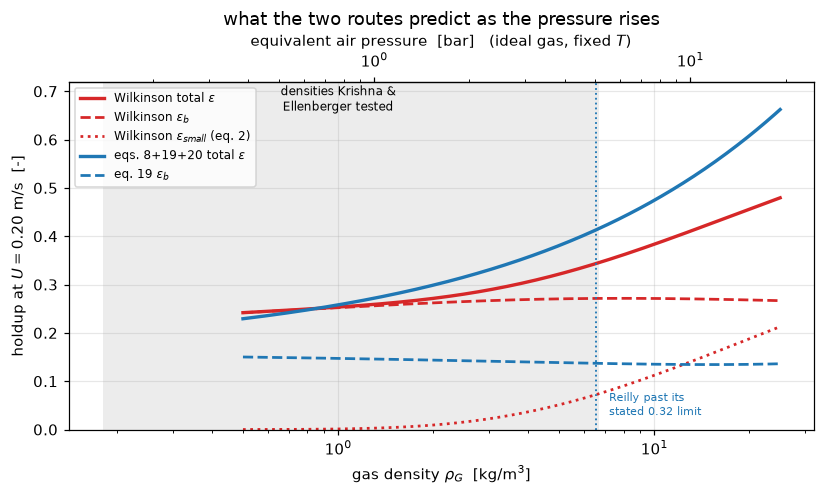

rho_G   1.3 kg/m3 (~ 1.0 bar air): Wilkinson eps 0.259 (eps_b 0.256), eqs. 8+19+20 eps 0.272 (eps_b 0.146)
rho_G   6.7 kg/m3 (~ 5.2 bar air): Wilkinson eps 0.346 (eps_b 0.271), eqs. 8+19+20 eps 0.416 (eps_b 0.137)
rho_G  13.0 kg/m3 (~10.0 bar air): Wilkinson eps 0.410 (eps_b 0.270), eqs. 8+19+20 eps 0.520 (eps_b 0.135)
rho_G  20.0 kg/m3 (~15.4 bar air): Wilkinson eps 0.456 (eps_b 0.268), eqs. 8+19+20 eps 0.608 (eps_b 0.135)

The two totals cross at rho_G = 0.9 kg/m3 (~0.7 bar of air).
Below it Wilkinson predicts MORE total holdup, because its overpredicted
large-bubble population outweighs its missing small one; above it, LESS,
because Reilly's eps_trans climbs steeply while Wilkinson's eps_b flattens.
The two eps_b curves never cross: Wilkinson is roughly twice eq. 19 throughout,
so the disagreement about the TOTAL is dominated by the transition closure.
Note also that beyond rho_G = 6.5 kg/m3 the blue curves use Reilly
outside the eps_trans <= 0.32 range its authors state it was deve

In [13]:
rho = np.logspace(np.log10(0.5), np.log10(25), 300)
P_bar = rho / GAS["air"]          # air at fixed T, rho_G linear in P, anchored on 1.3 kg/m3 = 1 bar
U_op = 0.20

w = wilkinson(U_op, rho)
er, vr, ur = reilly_transition(rho)
ke_b = eq19(np.maximum(U_op - ur, 0.0))

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(rho, w["eps"], "-", lw=2.2, color="tab:red", label="Wilkinson total $\\varepsilon$")
ax.plot(rho, w["eps_b"], "--", lw=1.8, color="tab:red", label="Wilkinson $\\varepsilon_b$")
ax.plot(rho, np.broadcast_to(w["eps_trans"], rho.shape), ":", lw=1.8, color="tab:red",
        label="Wilkinson $\\varepsilon_{small}$ (eq. 2)")
ax.plot(rho, ke_b + er * (1 - ke_b), "-", lw=2.2, color="tab:blue",
        label="eqs. 8+19+20 total $\\varepsilon$")
ax.plot(rho, ke_b, "--", lw=1.8, color="tab:blue", label="eq. 19 $\\varepsilon_b$")
ax.axvspan(GAS["helium"], GAS["SF6"], color="grey", alpha=0.15, lw=0)
ax.text(1.0, 0.66, "densities Krishna &\nEllenberger tested", fontsize=8, ha="center")
ax.axvline(r32, color="tab:blue", ls=":", lw=1.2)
ax.text(r32 * 1.1, 0.03, "Reilly past its\nstated 0.32 limit", fontsize=7.5, color="tab:blue")
ax.set(xscale="log", xlabel=r"gas density $\rho_G$  [kg/m$^3$]",
       ylabel=r"holdup at $U = 0.20$ m/s  [-]", ylim=(0, 0.72),
       title="what the two routes predict as the pressure rises")
sec = ax.secondary_xaxis("top", functions=(lambda r: r / GAS["air"], lambda p: p * GAS["air"]))
sec.set_xlabel("equivalent air pressure  [bar]   (ideal gas, fixed $T$)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

for rg in (1.3, 6.7, 13.0, 20.0):
    ww = wilkinson(U_op, rg)
    e2, _, u2 = reilly_transition(rg)
    kb = float(eq19(max(U_op - float(u2), 1e-9)))
    print(f"rho_G {rg:5.1f} kg/m3 (~{rg/GAS['air']:4.1f} bar air): "
          f"Wilkinson eps {float(ww['eps']):.3f} (eps_b {float(ww['eps_b']):.3f}), "
          f"eqs. 8+19+20 eps {kb + float(e2)*(1-kb):.3f} (eps_b {kb:.3f})")
def _gap(r):
    ww = wilkinson(U_op, r)
    e2, _, u2 = reilly_transition(r)
    kb = float(eq19(max(U_op - float(u2), 1e-9)))
    return float(ww["eps"]) - (kb + float(e2) * (1 - kb))


cross = brentq(_gap, 0.5, 25.0)
print(f"\nThe two totals cross at rho_G = {cross:.1f} kg/m3 (~{cross/GAS['air']:.1f} bar of air).")
print("Below it Wilkinson predicts MORE total holdup, because its overpredicted")
print("large-bubble population outweighs its missing small one; above it, LESS,")
print("because Reilly's eps_trans climbs steeply while Wilkinson's eps_b flattens.")
print("The two eps_b curves never cross: Wilkinson is roughly twice eq. 19 throughout,")
print("so the disagreement about the TOTAL is dominated by the transition closure.")
print(f"Note also that beyond rho_G = {r32:.1f} kg/m3 the blue curves use Reilly")
print("outside the eps_trans <= 0.32 range its authors state it was developed on.")
print("NEITHER branch is tested by anything on this page. Krishna and Ellenberger")
print("state the limit explicitly: their gas-density conclusion covers densities")
print("to 6.7 kg/m3 and 'the validity of this conclusion needs to be tested for")
print("higher gas densities'. Beyond the shaded band this figure is two")
print("extrapolations, drawn to show where they disagree, not to settle it.")

**The honest limits of this page.**

- The primary source was not read. Everything rests on Krishna and Ellenberger's
  reprint of Eqs. 1–4, verified on 600 dpi renders but not against Wilkinson's own
  paper. If they mis-set an exponent, this page inherits it. **What defends
  against that is the dimensional identity and the figure reproductions, and
  nothing else.** The rise-velocity groups come out exactly dimensionless, which
  constrains Eqs. 3 and 4; the source's own Notation list fixes the units; and
  this page's Eq. 2 reproduces the authors' plotted evaluation of it on two
  different figures. The $C^1$ continuity check does **not** contribute here: it
  reads back an exponent typed into the function being fitted, and an earlier
  draft of this page wrongly offered it as a transcription check. Note too what
  the dimensional identity does *not* reach: an exponent applied to an already
  dimensionless group — 0.757, −0.273, −0.077, 0.03, 0.077 — stays dimensionless
  whatever its value, so those five numbers rest on the 600 dpi render alone and
  on nothing computed here.
- **Wilkinson's stated range of validity is unknown here.** The original paper
  surely states one; this page can only observe where the equations behave and
  where they do not. Everything said about where Eq. 2 does or does not work is a
  statement about the formula, not a quotation of its authors — and 14 kg/m³ is
  where Eq. 2 crosses a fixed 0.15, which is a *lower bound* on adequacy and not
  a density at which the correlation becomes right.
- The only measurements used are the 63 Figure 11 points, one column, one liquid,
  four gases. The gas labels are unreliable, so all 63 are evaluated at air
  density and the resulting bias is quoted with its ±16 pp four-gas span. The
  liquid-property and diameter behaviour is discussed and not tested; those are
  Figures 7 and 9 and neither is digitised.
- The six Figure 6 numbers (three $\varepsilon_{df}$, three $U_{df}$) are read by
  eye against printed ticks to two significant figures. They are plot markers and
  a scale for a trend the paper states in words; they are not a dataset, have no
  CSV or sidecar, and none of the four validation checks uses them. The one place
  they carry a quantitative claim — the extrapolated measured level near
  14 kg/m³ — is labelled a three-point reconstruction on the page. **An earlier
  draft of this page carried coarser bands, 0.10–0.20 for $\varepsilon_{df}$ and
  0.02–0.035 m/s for $U_{df}$; the second of those is wrong** — Figure 6(b) reads
  0.0161 / 0.0230 / 0.0269 m/s, so the band excluded the helium measurement
  entirely and its upper edge sat 30 % above the largest one. Drawing either as a
  flat full-width band also asserted a density-independence the paper explicitly
  denies.
- The total-holdup comparison uses a reference built from the measured
  $\varepsilon_b$ plus Reilly's $\varepsilon_{df}$, because the total holdup for
  these runs is not published. It is indicative; the authors' own 0.24 against
  0.23 is the measurement-based version and is quoted as theirs.
- Nothing here reproduces Table 3, and no number on this page should be read as
  attempting to.

## Reuse

**Five standalone functions.** `wilkinson_transition`, `wilkinson_vb`,
`wilkinson`, `reilly_transition` and `eq19` take SI arguments — and *must* take
SI arguments, because two of them are unit-bound. `wilkinson(U, rho_G, liquid)`
runs the whole correlation from a superficial velocity and returns every
intermediate.

**Which transition closure to use.** Krishna and Ellenberger recommend Reilly's
Eq. 8 with $\varepsilon_{df} = \varepsilon_{\mathrm{trans}}$ and
$U_{df} = U_{\mathrm{trans}}$, and at atmospheric conditions that is clearly
right. **Do not read this page as saying that Wilkinson's Eq. 2 takes over at
high pressure — it does not.** Eq. 8 exceeds Eq. 2 at every density up to
1000 kg/m³, so there is no density at which the page's own figure shows Eq. 2
overtaking it, and the measured dense-phase voidage rises with density too, which
Eq. 2's ceiling of 0.5 caps. For a pressurised column **neither** closure has
support in this source: Eq. 8 was developed on data reaching
$\varepsilon_{\mathrm{trans}} = 0.32$, which SF₆ at 6.7 kg/m³ already exceeds,
and it gives $\varepsilon_{\mathrm{trans}} > 1$ above 70 kg/m³, so at the very
least clip it. Eq. 8 remains the better-supported of the two, and above
6.7 kg/m³ the honest answer is that this source does not settle the question.

**Which holdup correlation to use.** For $U > 0.1$ m/s and dispersion heights
above 1 m, Eq. 19 — see [`F1.4`](../F1.4-krishna-ellenberger-holdup/), which tests
it against these same 63 points and gets 13.8 %. Wilkinson's value is as a
*structure*: it is the correlation that says the split follows from a regime
transition, and if you need the transition itself, it is Eq. 2 or Reilly's Eq. 8
and nothing else in either paper.

**Where the closure is consumed.** [`F2.3`](../F2.3-slurry-bubble-column-ft/)
builds the `S7` two-phase bubble-column reactor that needs $\varepsilon_b$; `F1.9`
is the regime-transition page proper.

**Related pages.** [`F1.4`](../F1.4-krishna-ellenberger-holdup/) (the replacement
correlation and the data), [`F2.3`](../F2.3-slurry-bubble-column-ft/) (the reactor
model), `F1.9` (regime transition), [`F3.1`](../F3.1-hatta-regimes/) (gas–liquid
reaction regimes).

**Cite the origin, and the text it was read from.** The correlation is Wilkinson,
P. M., Spek, A. P. and van Dierendonck, L. L., *Design parameters estimation for
scale-up of high-pressure bubble columns*, AIChE Journal **38**(4) 544–554 (1992),
[doi:10.1002/aic.690380408](https://doi.org/10.1002/aic.690380408). The equations
used here were read from its reprint as Eqs. 1–4 of Krishna, R. and Ellenberger,
J., *Gas holdup in bubble column reactors operating in the churn-turbulent flow
regime*, AIChE Journal **42**(9) 2627–2634 (1996),
[doi:10.1002/aic.690420923](https://doi.org/10.1002/aic.690420923), which is also
the source of the Reilly Eq. 8 closure, the Table 2 properties and the Table 3
statistics.